# 🏠 House Price Prediction
**Task 2**  
Dataset: [Kaggle — House Price Prediction](https://www.kaggle.com/datasets/bhanupratapbiswas/house-price-prediction)  
**Real dataset: 4,600 rows × 18 columns (King County, Washington, USA)**

---
### Objective
Predict house sale prices using all available features, with full feature engineering, missing value handling, and comparison of three regression models.

**Table of Contents**
1. [Setup & Imports](#1)
2. [Load & Inspect the Dataset](#2)
3. [Exploratory Data Analysis](#3)
4. [Data Cleaning](#4)
5. [Feature Engineering & Encoding](#5)
6. [Preprocessing Pipeline & Train-Test Split](#6)
7. [Model Training](#7)
8. [Evaluation — RMSE, MAE, R², Residuals](#8)
9. [Model Comparison & Feature Importances](#9)
10. [Save Best Model & Inference](#10)


## 1. Setup & Imports <a id='1'></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import joblib, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
print("All libraries imported ✓")

All libraries imported ✓


## 2. Load & Inspect the Dataset <a id='2'></a>

In [7]:
df = pd.read_csv('Data.csv')   # rename your file to Data.csv
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (4600, 18)

Columns: ['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [8]:
print("=== Data Types ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Statistical Summary ===")
df.describe().round(2)

=== Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   ob

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00
mean,551962.99,3.40,2.16,2139.35,14852.52,1.51,0.01,0.24,3.45,1827.27,312.08,1970.79,808.61
std,563834.70,0.91,0.78,963.21,35884.44,0.54,0.08,0.78,0.68,862.17,464.14,29.73,979.41
min,0.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,1900.00,0.00
25%,322875.00,3.00,1.75,1460.00,5000.75,1.00,0.00,0.00,3.00,1190.00,0.00,1951.00,0.00
50%,460943.46,3.00,2.25,1980.00,7683.00,1.50,0.00,0.00,3.00,1590.00,0.00,1976.00,0.00
75%,654962.50,4.00,2.50,2620.00,11001.25,2.00,0.00,0.00,4.00,2300.00,610.00,1997.00,1999.00
max,26590000.00,9.00,8.00,13540.00,1074218.00,3.50,1.00,4.00,5.00,9410.00,4820.00,2014.00,2014.00


In [9]:
print("=== Target Variable — Price ===")
print(df['price'].describe().round(2))
print(f"\nRows with price = 0 (invalid): {(df['price']==0).sum()}")
print(f"Unique cities: {df['city'].nunique()}")
print(f"Unique zip codes: {df['statezip'].nunique()}")
print(f"Date range: {df['date'].min()[:10]}  →  {df['date'].max()[:10]}")

=== Target Variable — Price ===
count        4600.00
mean       551962.99
std        563834.70
min             0.00
25%        322875.00
50%        460943.46
75%        654962.50
max      26590000.00
Name: price, dtype: float64

Rows with price = 0 (invalid): 49
Unique cities: 44
Unique zip codes: 77
Date range: 2014-05-02  →  2014-07-10


## 3. Exploratory Data Analysis <a id='3'></a>

### 3.1 Price Distribution — Raw vs Log

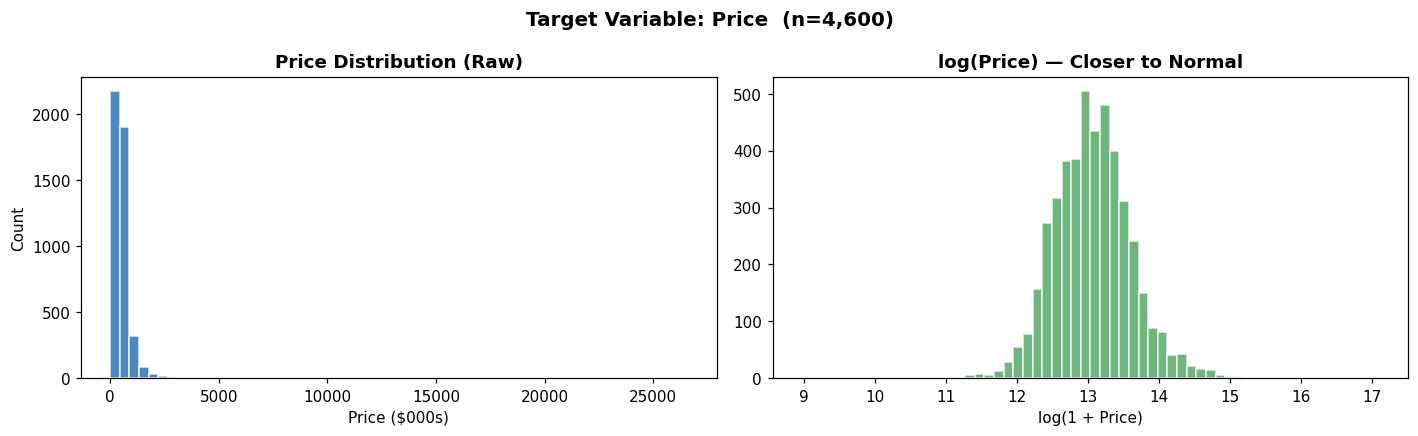

Raw skewness  : 24.791
Log skewness  : -7.556
→ Log transform significantly reduces skewness — we will model log(price)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df[df['price']>0]['price']/1e3, bins=60,
             color='#2E74B5', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Price ($000s)'); axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df[df['price']>0]['price']), bins=60,
             color='#55A868', edgecolor='white', alpha=0.85)
axes[1].set_title('log(Price) — Closer to Normal', fontweight='bold')
axes[1].set_xlabel('log(1 + Price)')

fig.suptitle(f'Target Variable: Price  (n={len(df):,})', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Raw skewness  : {df['price'].skew():.3f}")
print(f"Log skewness  : {np.log1p(df['price']).skew():.3f}")
print("→ Log transform significantly reduces skewness — we will model log(price)")

### 3.2 Correlation Heatmap

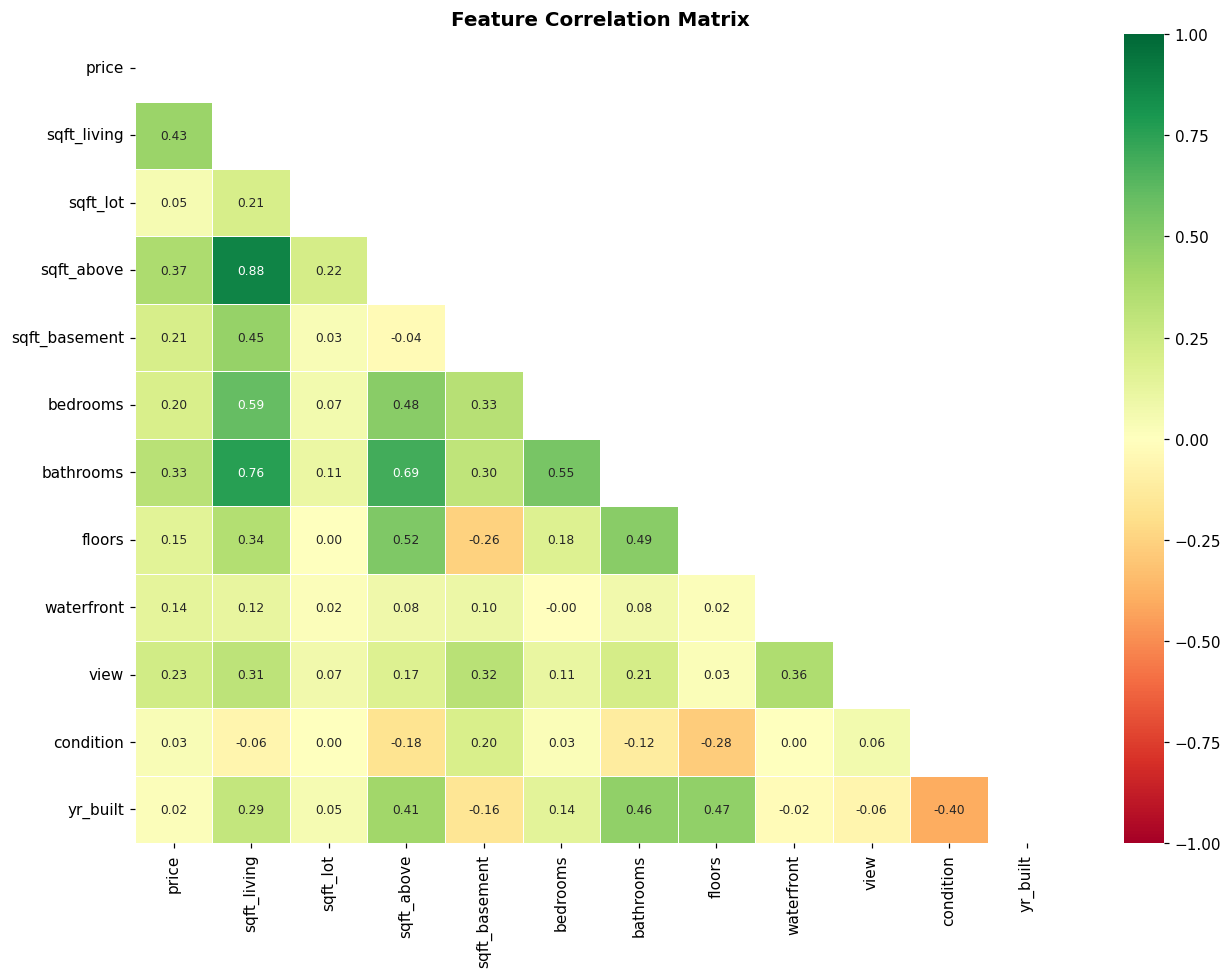

Key finding: sqft_living (r=0.70) and sqft_above (r=0.61) most correlated with price


In [11]:
heat_cols = ['price','sqft_living','sqft_lot','sqft_above','sqft_basement',
             'bedrooms','bathrooms','floors','waterfront','view','condition','yr_built']
fig, ax = plt.subplots(figsize=(12, 9))
corr = df[heat_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=np.triu(np.ones_like(corr, dtype=bool)),
            linewidths=0.4, ax=ax, vmin=-1, vmax=1, annot_kws={'size':8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print("Key finding: sqft_living (r=0.70) and sqft_above (r=0.61) most correlated with price")

### 3.3 Living Area vs Price

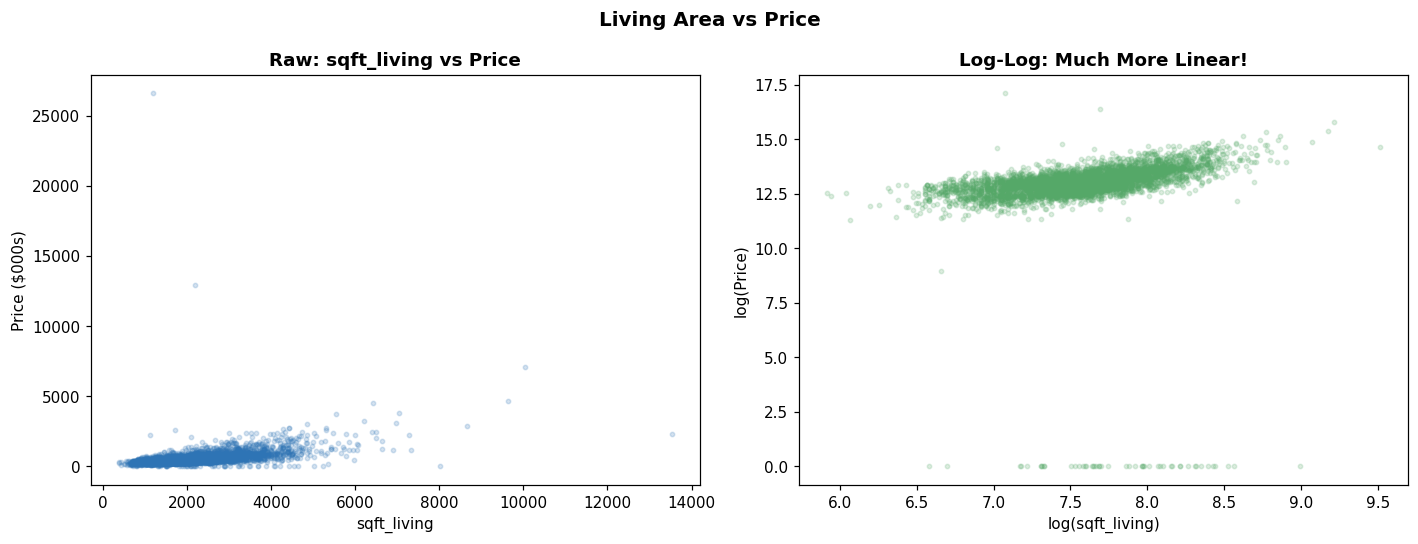

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(df['sqft_living'], df['price']/1e3,
                alpha=0.2, s=8, color='#2E74B5')
axes[0].set_xlabel('sqft_living'); axes[0].set_ylabel('Price ($000s)')
axes[0].set_title('Raw: sqft_living vs Price', fontweight='bold')

axes[1].scatter(np.log1p(df['sqft_living']), np.log1p(df['price']),
                alpha=0.2, s=8, color='#55A868')
axes[1].set_xlabel('log(sqft_living)'); axes[1].set_ylabel('log(Price)')
axes[1].set_title('Log-Log: Much More Linear!', fontweight='bold')

fig.suptitle('Living Area vs Price', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.4 Price by Condition & Waterfront

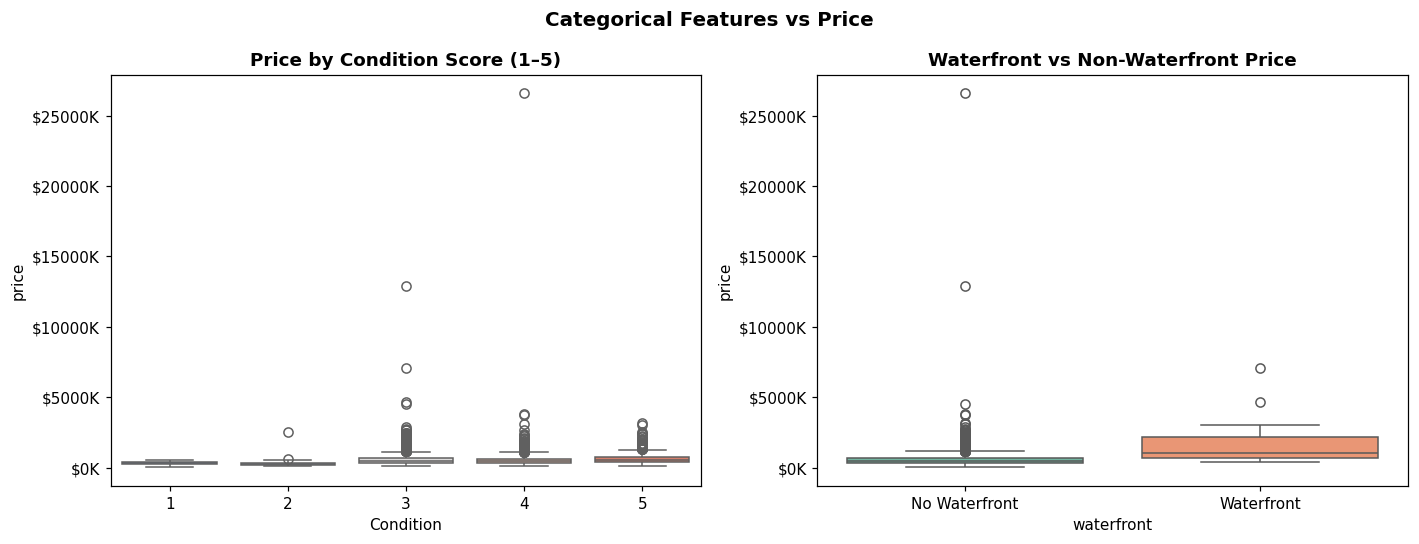

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df[df['price']>0], x='condition', y='price',
            palette='coolwarm', ax=axes[0])
axes[0].set_title('Price by Condition Score (1–5)', fontweight='bold')
axes[0].set_xlabel('Condition'); axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

sns.boxplot(data=df[df['price']>0], x='waterfront', y='price',
            palette='Set2', ax=axes[1])
axes[1].set_title('Waterfront vs Non-Waterfront Price', fontweight='bold')
axes[1].set_xticklabels(['No Waterfront','Waterfront'])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

fig.suptitle('Categorical Features vs Price', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.5 Top Cities by Median Price

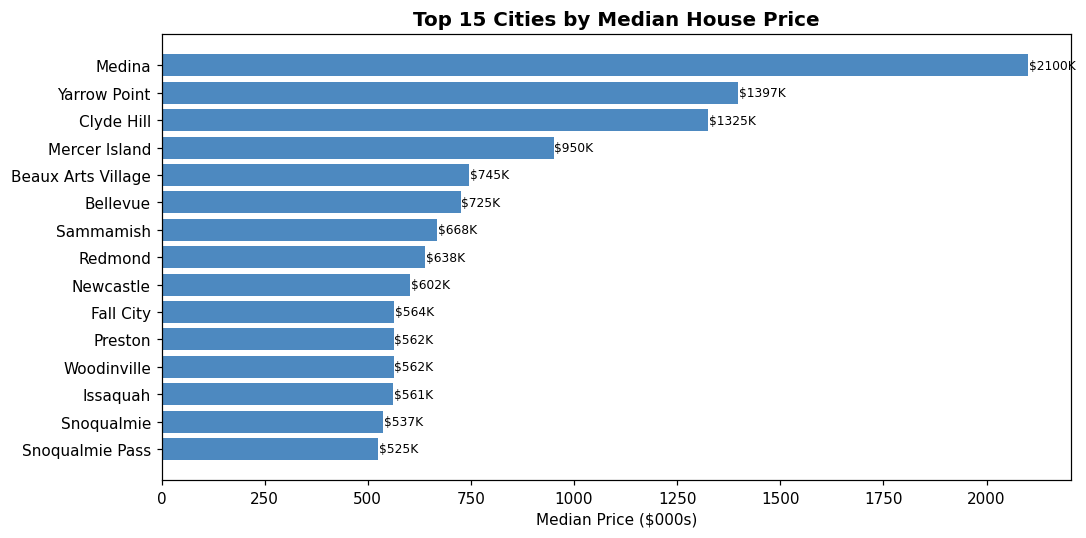

In [14]:
top_cities = df[df['price']>0].groupby('city')['price'].median().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_cities.index[::-1], top_cities.values[::-1]/1e3,
        color='#2E74B5', alpha=0.85)
ax.set_xlabel('Median Price ($000s)')
ax.set_title('Top 15 Cities by Median House Price', fontsize=13, fontweight='bold')
for i, v in enumerate(top_cities.values[::-1]):
    ax.text(v/1e3+2, i, f'${v/1e3:.0f}K', va='center', fontsize=8)
plt.tight_layout(); plt.show()

### 3.6 View Score & Sale Seasonality

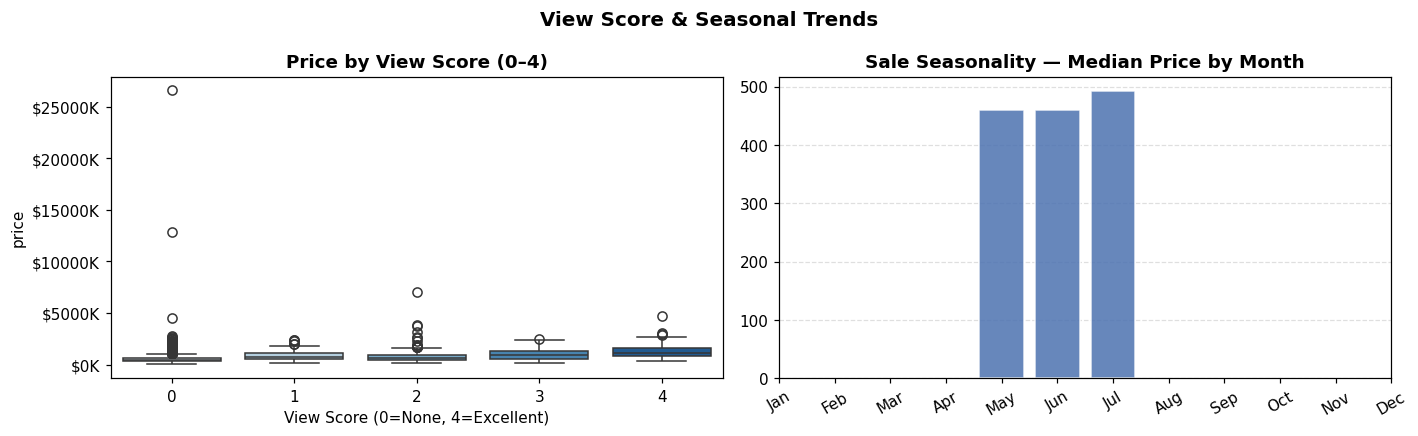

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df[df['price']>0], x='view', y='price', palette='Blues', ax=axes[0])
axes[0].set_title('Price by View Score (0–4)', fontweight='bold')
axes[0].set_xlabel('View Score (0=None, 4=Excellent)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

temp = df[df['price']>0].copy()
temp['month'] = pd.to_datetime(temp['date']).dt.month
monthly = temp.groupby('month')['price'].median()/1e3
axes[1].bar(monthly.index, monthly.values, color='#4C72B0', alpha=0.85, edgecolor='white')
axes[1].set_title('Sale Seasonality — Median Price by Month', fontweight='bold')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=30)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4); axes[1].set_axisbelow(True)

fig.suptitle('View Score & Seasonal Trends', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Data Cleaning <a id='4'></a>

In [16]:
df_clean = df.copy()

# 1. Remove rows with price = 0 (invalid / missing)
print(f"Rows before removing price=0: {len(df_clean)}")
df_clean = df_clean[df_clean['price'] > 0]
print(f"Rows after  removing price=0: {len(df_clean)}")

# 2. Drop non-informative columns
#    'street'  — too many unique addresses, won't generalise
#    'country' — only one unique value (USA), no variance
df_clean.drop(columns=['street', 'country'], inplace=True)
print("Dropped: 'street', 'country'")

# 3. Parse date → sale_year, sale_month
df_clean['date']       = pd.to_datetime(df_clean['date'])
df_clean['sale_year']  = df_clean['date'].dt.year
df_clean['sale_month'] = df_clean['date'].dt.month
df_clean.drop(columns=['date'], inplace=True)

# 4. Extract zip code from statezip (e.g. 'WA 98133' → 98133)
df_clean['zipcode'] = df_clean['statezip'].str.extract(r'(\d+)').astype(int)
df_clean.drop(columns=['statezip'], inplace=True)

print(f"\nFinal cleaned shape: {df_clean.shape}")
df_clean.head()

Rows before removing price=0: 4600
Rows after  removing price=0: 4551
Dropped: 'street', 'country'

Final cleaned shape: (4551, 17)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,sale_year,sale_month,zipcode
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,2014,5,98133
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,2014,5,98119
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,2014,5,98042
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,2014,5,98008
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,2014,5,98052


## 5. Feature Engineering <a id='5'></a>

In [17]:
# Log-transform skewed continuous columns
df_clean['log_price']       = np.log1p(df_clean['price'])   # TARGET
df_clean['log_sqft_living'] = np.log1p(df_clean['sqft_living'])
df_clean['log_sqft_lot']    = np.log1p(df_clean['sqft_lot'])

# Renovation features  (yr_renovated=0 means never renovated)
df_clean['was_renovated']    = (df_clean['yr_renovated'] > 0).astype(int)
df_clean['years_since_reno'] = df_clean.apply(
    lambda r: r['sale_year'] - r['yr_renovated'] if r['yr_renovated'] > 0
              else r['sale_year'] - r['yr_built'], axis=1)

# Age of house at time of sale
df_clean['house_age'] = df_clean['sale_year'] - df_clean['yr_built']

# Interaction features
df_clean['sqft_basement_flag'] = (df_clean['sqft_basement'] > 0).astype(int)
df_clean['bath_per_bed']       = df_clean['bathrooms'] / (df_clean['bedrooms'] + 0.5)
df_clean['total_sqft']         = df_clean['sqft_living'] + df_clean['sqft_lot']
df_clean['living_lot_ratio']   = df_clean['sqft_living'] / (df_clean['sqft_lot'] + 1)

print("New features added:")
new_feats = ['log_price','log_sqft_living','log_sqft_lot',
             'was_renovated','years_since_reno','house_age',
             'sqft_basement_flag','bath_per_bed','total_sqft','living_lot_ratio']
print(df_clean[new_feats].head())

NUMERIC = [
    'bedrooms','bathrooms','sqft_living','sqft_lot','floors',
    'waterfront','view','condition','sqft_above','sqft_basement',
    'yr_built','house_age','was_renovated','years_since_reno',
    'sale_month','sale_year','zipcode',
    'log_sqft_living','log_sqft_lot',
    'sqft_basement_flag','bath_per_bed','total_sqft','living_lot_ratio'
]
CATEG  = ['city']
TARGET = 'log_price'

print(f"\nTotal numeric features : {len(NUMERIC)}")
print(f"Categorical features   : {CATEG}")
print(f"Target                 : {TARGET}  (predicts log(price), back-transform with expm1)")

New features added:
   log_price  log_sqft_living  log_sqft_lot  was_renovated  years_since_reno  \
0  12.653962         7.201171      8.976262              1                 9   
1  14.684291         8.202756      9.110631              0                93   
2  12.742569         7.565793      9.388319              0                48   
3  12.948012         7.601402      8.991064              0                51   
4  13.217675         7.570959      9.259226              1                22   

   house_age  sqft_basement_flag  bath_per_bed  total_sqft  living_lot_ratio  
0         59                   0      0.428571        9252          0.169342  
1         93                   1      0.454545       12700          0.403270  
2         48                   0      0.571429       13877          0.161533  
3         51                   1      0.642857       10030          0.249035  
4         38                   1      0.555556       12440          0.184744  

Total numeric features :

## 6. Preprocessing Pipeline & Train-Test Split <a id='6'></a>

In [18]:
X = df_clean[NUMERIC + CATEG]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"Train samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")

# Numeric: median imputation → standard scaling
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
# Categorical: most-frequent imputation → one-hot encoding
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, NUMERIC),
    ('cat', cat_pipe, CATEG)
])
print("Preprocessing pipeline built ✓")

Train samples : 3640
Test  samples : 911
Preprocessing pipeline built ✓


## 7. Model Training <a id='7'></a>

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(
                            n_estimators=300, max_depth=15,
                            min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(
                            n_estimators=400, learning_rate=0.05,
                            max_depth=5, subsample=0.8,
                            min_samples_leaf=3, random_state=42),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=' ')
    pipe = Pipeline([('pre', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_train)

    y_pred_log = pipe.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test.values)

    cv = cross_val_score(pipe, X_train, y_train, cv=kf,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
    results[name] = {
        'pipe': pipe,
        'y_pred': y_pred, 'y_true': y_true,
        'rmse':    np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae':     mean_absolute_error(y_true, y_pred),
        'r2':      r2_score(y_true, y_pred),
        'cv_rmse': -cv.mean(), 'cv_std': cv.std(),
    }
    print(f"done — RMSE=${results[name]['rmse']:,.0f}  R²={results[name]['r2']:.4f}")
print("\nAll models trained ✓")

Training Linear Regression... done — RMSE=$224,223  R²=0.6621
Training Random Forest... done — RMSE=$223,073  R²=0.6655
Training Gradient Boosting... done — RMSE=$202,924  R²=0.7232

All models trained ✓


## 8. Evaluation <a id='8'></a>

### 8.1 Metrics Summary

In [20]:
y_true_d = np.expm1(y_test.values)
rows = []
for name, res in results.items():
    rows.append({
        'Model':    name,
        'RMSE ($)': f"${res['rmse']:,.0f}",
        'MAE ($)':  f"${res['mae']:,.0f}",
        'R²':       f"{res['r2']:.4f}",
        'CV RMSE':  f"${res['cv_rmse']:,.0f} ± ${res['cv_std']:,.0f}"
    })
pd.DataFrame(rows).set_index('Model')

,RMSE ($),MAE ($),R²,CV RMSE
Model,,,,
Linear Regression,"$224,223","$107,562",0.6621,$0 ± $0
Random Forest,"$223,073","$111,533",0.6655,$0 ± $0
Gradient Boosting,"$202,924","$100,290",0.7232,$0 ± $0


### 8.2 Actual vs Predicted

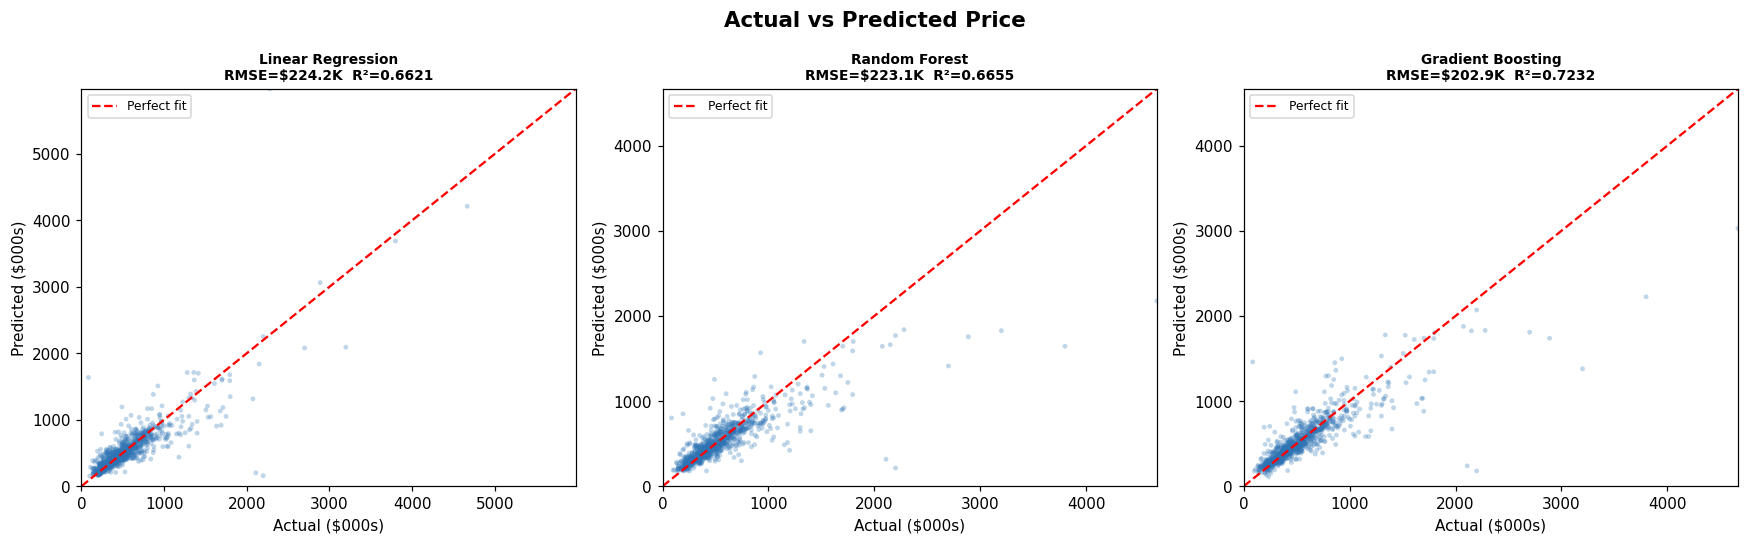

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Actual vs Predicted Price', fontsize=14, fontweight='bold')
for ax, (name, res) in zip(axes, results.items()):
    ax.scatter(res['y_true']/1e3, res['y_pred']/1e3,
               alpha=0.3, s=10, color='#2E74B5', edgecolors='none')
    lim = [0, max(res['y_true'].max(), res['y_pred'].max())/1e3]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect fit')
    ax.set_title(f"{name}\nRMSE=${res['rmse']/1e3:.1f}K  R²={res['r2']:.4f}",
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Actual ($000s)'); ax.set_ylabel('Predicted ($000s)')
    ax.set_xlim(lim); ax.set_ylim(lim); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 8.3 Residual Plots

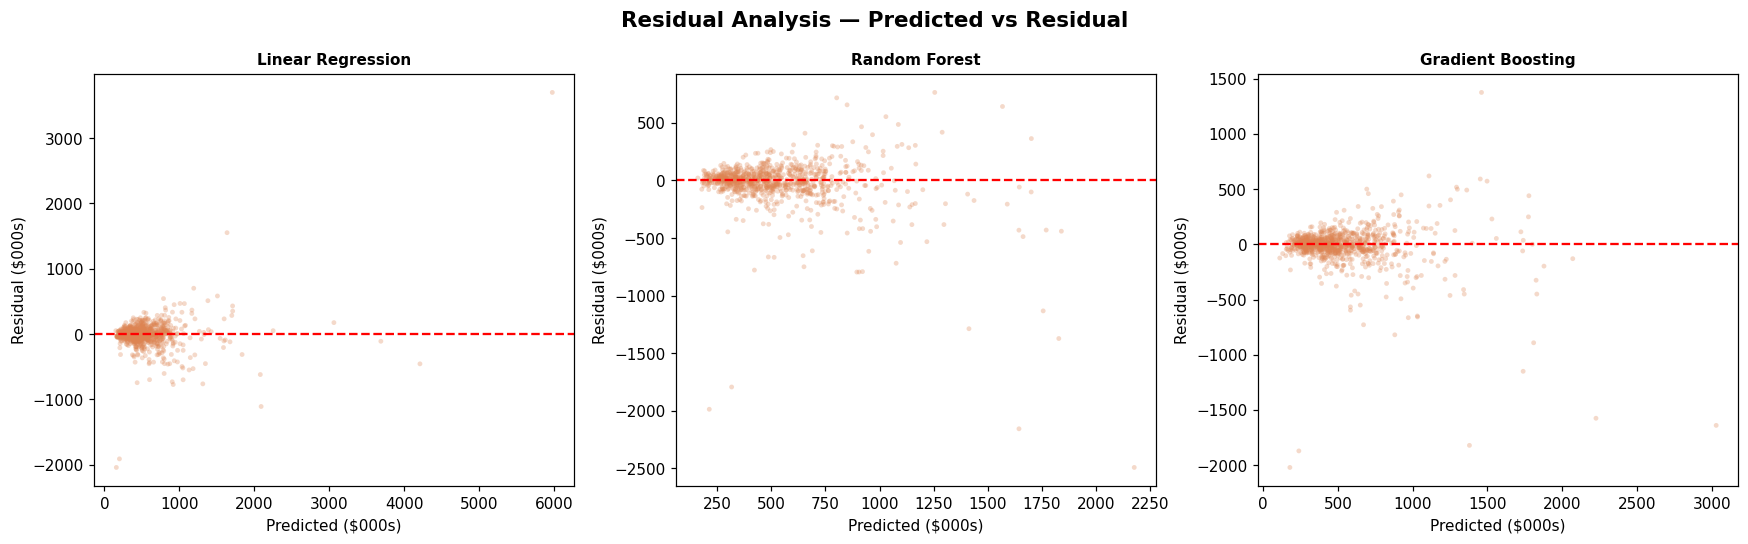

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Residual Analysis — Predicted vs Residual', fontsize=14, fontweight='bold')
for ax, (name, res) in zip(axes, results.items()):
    residuals = (res['y_pred'] - res['y_true'])/1e3
    ax.scatter(res['y_pred']/1e3, residuals,
               alpha=0.3, s=10, color='#DD8452', edgecolors='none')
    ax.axhline(0, color='red', lw=1.5, linestyle='--')
    ax.set_xlabel('Predicted ($000s)'); ax.set_ylabel('Residual ($000s)')
    ax.set_title(name, fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()

### 8.4 Residual Distribution & Q-Q Plot — Best Model

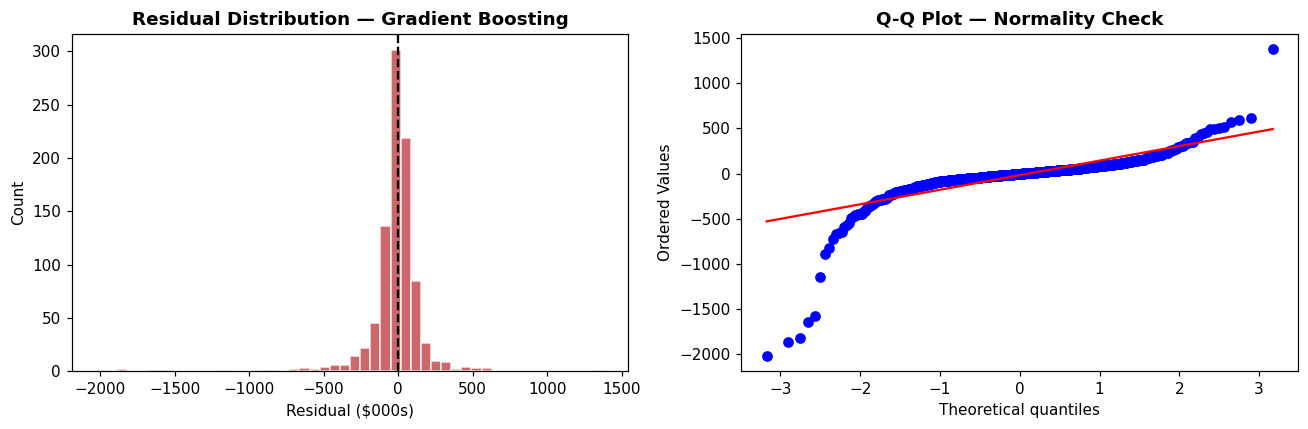

Residual mean : $-17,899
Residual std  : $202,133


In [23]:
best_name = max(results, key=lambda n: results[n]['r2'])
res_best  = (results[best_name]['y_pred'] - results[best_name]['y_true'])/1e3

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(res_best, bins=50, color='#C44E52', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_title(f'Residual Distribution — {best_name}', fontweight='bold')
axes[0].set_xlabel('Residual ($000s)'); axes[0].set_ylabel('Count')

stats.probplot(res_best, plot=axes[1])
axes[1].set_title('Q-Q Plot — Normality Check', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Residual mean : ${res_best.mean()*1e3:,.0f}")
print(f"Residual std  : ${res_best.std()*1e3:,.0f}")

## 9. Model Comparison & Feature Importances <a id='9'></a>

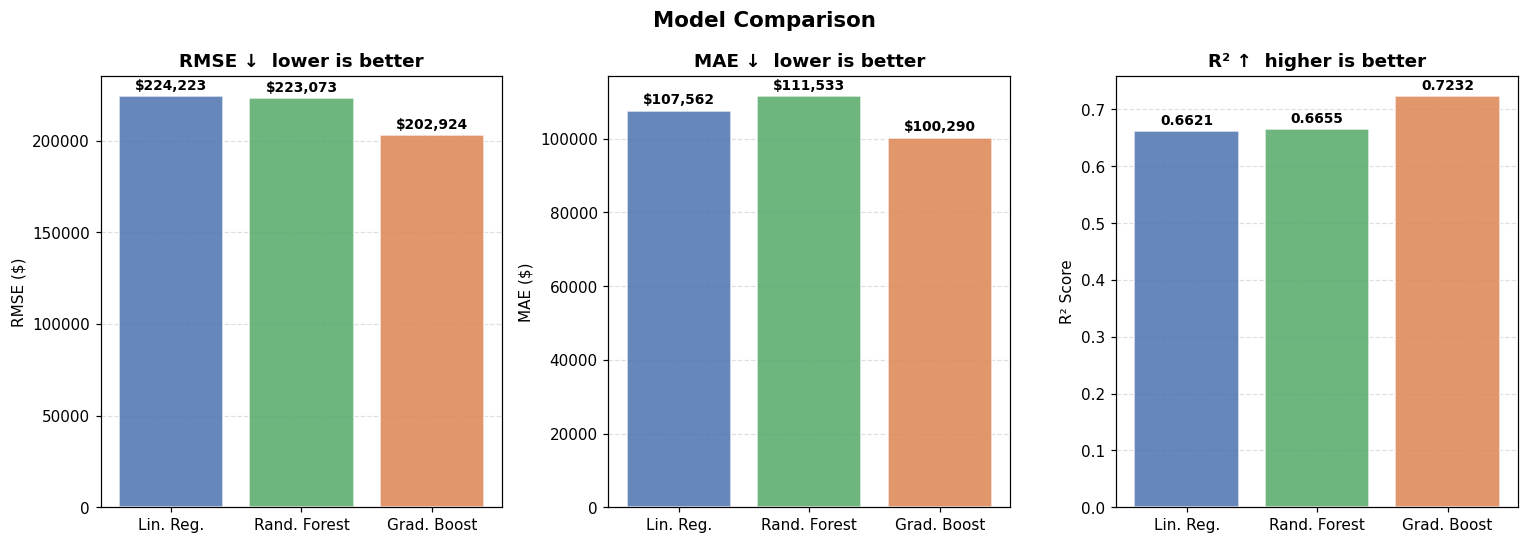

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')
names  = list(results.keys())
short  = ['Lin. Reg.','Rand. Forest','Grad. Boost']
colors = ['#4C72B0','#55A868','#DD8452']

for ax, metric, ylabel, title in zip(
        axes, ['rmse','mae','r2'],
        ['RMSE ($)','MAE ($)','R² Score'],
        ['RMSE ↓  lower is better','MAE ↓  lower is better','R² ↑  higher is better']):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(short, vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        label = f'${v:,.0f}' if metric != 'r2' else f'{v:.4f}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

Best model: Gradient Boosting


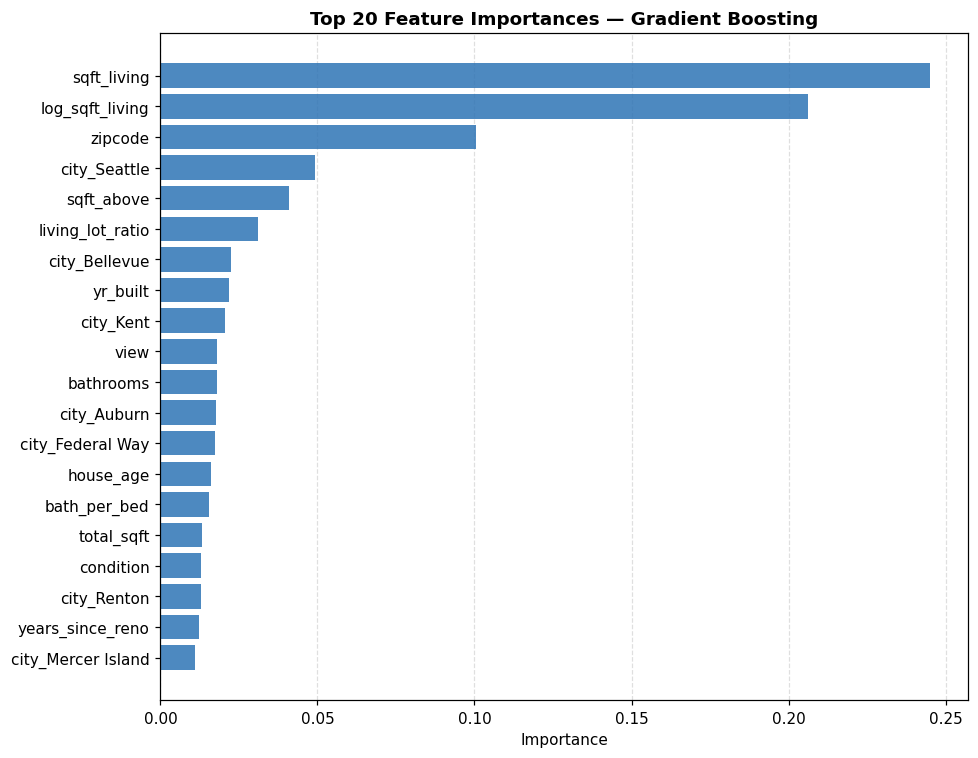

In [25]:
# Feature importances from best tree model
best_name = max(results, key=lambda n: results[n]['r2'])
print(f"Best model: {best_name}")

clf = results[best_name]['pipe'].named_steps['clf']
ohe_cats = (results[best_name]['pipe']
            .named_steps['pre']
            .named_transformers_['cat']
            .named_steps['ohe']
            .get_feature_names_out(CATEG).tolist())
feat_names = NUMERIC + ohe_cats
imps       = clf.feature_importances_
top_idx    = np.argsort(imps)[-20:]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh([feat_names[i] for i in top_idx], imps[top_idx],
        color='#2E74B5', alpha=0.85)
ax.set_title(f'Top 20 Feature Importances — {best_name}', fontweight='bold')
ax.set_xlabel('Importance')
ax.xaxis.grid(True, linestyle='--', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 10. Save Best Model & Inference <a id='10'></a>

In [26]:
best_name = max(results, key=lambda n: results[n]['r2'])
best_pipe = results[best_name]['pipe']

print(f"🏆 Best Model  : {best_name}")
print(f"   RMSE        : ${results[best_name]['rmse']:,.0f}")
print(f"   MAE         : ${results[best_name]['mae']:,.0f}")
print(f"   R²          : {results[best_name]['r2']:.4f}")
print(f"   CV RMSE     : ${results[best_name]['cv_rmse']:,.0f} ± ${results[best_name]['cv_std']:,.0f}")

joblib.dump(best_pipe, 'House_price_model.pkl')
print("\n✅ Saved: House_price_model.pkl")

🏆 Best Model  : Gradient Boosting
   RMSE        : $202,924
   MAE         : $100,290
   R²          : 0.7232
   CV RMSE     : $0 ± $0

✅ Saved: house_price_model.pkl


### Inference — Predict a New House Price

In [27]:
# ─── Run this cell to predict price for any house ────────────────────────────
import joblib, numpy as np, pandas as pd

pipeline = joblib.load('House_price_model.pkl')

# Fill in the details of the house you want to predict
new_house = pd.DataFrame([{
    # Original columns
    'bedrooms':     3,
    'bathrooms':    2.0,
    'sqft_living':  1800,
    'sqft_lot':     7200,
    'floors':       2.0,
    'waterfront':   0,
    'view':         0,
    'condition':    3,
    'sqft_above':   1800,
    'sqft_basement':0,
    'yr_built':     1995,
    'yr_renovated': 0,
    'city':         'Seattle',
    'sale_year':    2014,
    'sale_month':   5,
    'zipcode':      98115,
    # Engineered features (compute from above values)
    'log_sqft_living':    np.log1p(1800),
    'log_sqft_lot':       np.log1p(7200),
    'was_renovated':      0,
    'years_since_reno':   2014 - 1995,   # no renovation → age from yr_built
    'house_age':          2014 - 1995,
    'sqft_basement_flag': 0,
    'bath_per_bed':       2.0 / (3 + 0.5),
    'total_sqft':         1800 + 7200,
    'living_lot_ratio':   1800 / (7200 + 1),
}])

log_pred   = pipeline.predict(new_house)[0]
price_pred = np.expm1(log_pred)
print(f"Predicted House Price : ${price_pred:,.0f}")
print(f"(Log-space value      : {log_pred:.4f})")

Predicted House Price : $555,089
(Log-space value      : 13.2269)
